# SAM Fracture Segmentation — Clean Pipeline

**Сайжруулалтууд:**
- CLAHE preprocessing (хугарлын контраст тодруулна)
- Металл implant шүүлтүүр (screw, rod, plate бүхий зургийг хасна)
- Сулруулсан quality filter: score≥0.70, area 0.3%–30%
- 4 dataset: FracAtlas · YOLOBoneFracture · BoneFractureCVProject · BoneFractureLiang

**Output:** `fracture_sam_final.json` + зургууд → Google Drive

In [ ]:
# Cell 1 — GPU
import torch
print('GPU:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('Device:', torch.cuda.get_device_name(0))
    print('Memory:', round(torch.cuda.get_device_properties(0).total_memory/1e9,1), 'GB')
else:
    raise RuntimeError('GPU байхгүй — Runtime > Change runtime type > T4 GPU')
!nvidia-smi | head -8

GPU: True
Device: Tesla T4
Memory: 15.6 GB
Fri May 22 11:51:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|


In [ ]:
# Cell 2 — Install
!pip install git+https://github.com/facebookresearch/segment-anything.git -q
!pip install kaggle opencv-python-headless tqdm pycocotools -q
print('Done.')

  Preparing metadata (setup.py) ... done
Done.


In [ ]:
# Cell 3 — SAM ViT-H checkpoint
import os
CKPT = '/content/sam_vit_h.pth'
if not os.path.exists(CKPT):
    !wget -q --show-progress https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth -O {CKPT}
print('Checkpoint ready:', os.path.getsize(CKPT)//1e6, 'MB')

/content/sam_vit_h. 100%[===================>]   2.39G  99.1MB/s    in 16s     
Checkpoint ready: 2564.0 MB


In [ ]:
# Cell 4 — Drive + Kaggle
from google.colab import drive, files
import os, shutil

drive.mount('/content/drive')

KD = os.path.expanduser('~/.kaggle')
os.makedirs(KD, exist_ok=True)
dk = '/content/drive/MyDrive/kaggle.json'
if os.path.exists(dk):
    shutil.copy(dk, f'{KD}/kaggle.json')
    os.chmod(f'{KD}/kaggle.json', 0o600)
    print('Kaggle credentials loaded.')
else:
    up = files.upload()
    with open(f'{KD}/kaggle.json','wb') as f: f.write(list(up.values())[0])
    os.chmod(f'{KD}/kaggle.json', 0o600)
    shutil.copy(f'{KD}/kaggle.json', dk)
    print('Saved to Drive.')
!kaggle datasets list 2>&1 | head -2

Mounted at /content/drive
Kaggle credentials loaded.
ref                                                                      title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  


In [ ]:
# Cell 5 — Dataset татах
import os
ROOT = '/content/datasets'
os.makedirs(ROOT, exist_ok=True)

datasets = [
    ('shyamgupta196/fracatlas',                                  'FracAtlas'),
    ('deepakat002/yolo-object-detection-data-bone-fracture',     'YOLOBoneFracture'),
    ('pkdarabi/bone-fracture-detection-computer-vision-project', 'BoneFractureCVProject'),
]

for slug, name in datasets:
    out = f'{ROOT}/{name}'
    if os.path.exists(out) and os.listdir(out):
        print(f'{name}: already downloaded')
        continue
    os.makedirs(out, exist_ok=True)
    print(f'Downloading {name}...')
    ret = os.system(f'kaggle datasets download {slug} --path {out} --unzip -q')
    n   = sum(len(fs) for _,_,fs in os.walk(out))
    print(f'  Done — {n} files' if n else '  WARNING: 0 files (403?)')

# 4-р dataset: дараалан туршина, эхнийх нь амжвал зогсоно
CANDIDATES_4TH = [
    ('dhavalrupapara/fracture-detection-dataset',           'BoneFracture4th'),
    ('preetviradiya/bone-fracture-segmentation',            'BoneFracture4th'),
    ('thetavisal/bone-fracture-detection',                  'BoneFracture4th'),
    ('tommyngx/bonefracture',                               'BoneFracture4th'),
    ('abrahamanderson/bone-fracture-detection',             'BoneFracture4th'),
]

out4 = f'{ROOT}/BoneFracture4th'
if os.path.exists(out4) and os.listdir(out4):
    print('BoneFracture4th: already downloaded')
else:
    os.makedirs(out4, exist_ok=True)
    for slug, name in CANDIDATES_4TH:
        print(f'Trying {slug}...')
        os.system(f'kaggle datasets download {slug} --path {out4} --unzip -q')
        n = sum(len(fs) for _,_,fs in os.walk(out4))
        if n > 0:
            print(f'  OK — {n} files ({slug})')
            break
        print(f'  403 — next...')
    else:
        print('  4th dataset: бүгд 403. 3 dataset-аар үргэлжлүүлнэ.')

print('\nAll done.')


  Done — 8169 files
  Done — 8297 files
  Done — 16596 files
Trying dhavalrupapara/fracture-detection-dataset...
  403 — next...
Trying preetviradiya/bone-fracture-segmentation...
  403 — next...
Trying thetavisal/bone-fracture-detection...
  403 — next...
Trying tommyngx/bonefracture...
  403 — next...
Trying abrahamanderson/bone-fracture-detection...
  403 — next...
  4th dataset: бүгд 403. 3 dataset-аар үргэлжлүүлнэ.

All done.


In [ ]:
# Cell 6 — SAM + utility функцүүд
import torch, cv2, numpy as np, json
from pathlib import Path
from tqdm import tqdm
from segment_anything import sam_model_registry, SamPredictor

print('Loading SAM ViT-H...')
sam = sam_model_registry['vit_h'](checkpoint='/content/sam_vit_h.pth')
sam.to('cuda')
predictor = SamPredictor(sam)
print('SAM loaded.\n')

# ── Тохиргоо ──────────────────────────────────────────────────────────────────
SAM_SIZE      = 1024
SCORE_THRESH  = 0.70    # 0.82 → 0.70  (X-ray дээр score бага байдаг)
MIN_AREA      = 0.003   # 0.3% — хугарлын шугаас нарийн байдаг
MAX_AREA      = 0.30    # 30%
METAL_THRESH  = 0.018   # зурагт 1.8%+ хэт цагаан → металл implant

def clahe(img_rgb):
    """CLAHE: хугарлын шугамын контрастыг тодруулна."""
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    cl  = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8,8))
    lab[:,:,0] = cl.apply(lab[:,:,0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

def has_metal(img_rgb):
    """Металл implant (screw/rod/plate) илрүүлэх — хэт цагаан бүс."""
    gray   = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    ratio  = (gray > 240).sum() / gray.size
    return ratio > METAL_THRESH

def load_img(path):
    img = cv2.imread(str(path))
    if img is None: return None, None, 0, 0, 1.0
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = rgb.shape[:2]
    sc   = SAM_SIZE / max(h,w) if max(h,w) > SAM_SIZE else 1.0
    rs   = cv2.resize(rgb, (int(w*sc), int(h*sc))) if sc < 1.0 else rgb
    return clahe(rs), rs, h, w, sc

def to_poly(mask, oh, ow):
    if mask.shape != (oh, ow):
        mask = cv2.resize(mask.astype(np.uint8),(ow,oh),
                          interpolation=cv2.INTER_NEAREST).astype(bool)
    m8 = (mask*255).astype(np.uint8)
    cs, _ = cv2.findContours(m8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    polys = []
    for c in cs:
        if cv2.contourArea(c) < 30: continue
        ap = cv2.approxPolyDP(c, 0.002*cv2.arcLength(c,True), True)
        if len(ap) < 3: continue
        fl = ap.reshape(-1,2).astype(float).ravel().tolist()
        if len(fl) >= 6: polys.append(fl)
    return polys

def sam_predict(img_s, box, oh, ow):
    masks, scores, _ = predictor.predict(box=box, multimask_output=True)
    best  = np.argmax(scores)
    bmask = masks[best]
    sc    = float(scores[best])
    if sc < SCORE_THRESH: return None, None, None
    ar = bmask.sum() / (bmask.shape[0]*bmask.shape[1])
    if not (MIN_AREA <= ar <= MAX_AREA): return None, None, None
    polys = to_poly(bmask, oh, ow)
    if not polys: return None, None, None
    return bmask, polys, sc

def yolo_box(parts, h, w):
    vs = [float(v) for v in parts[1:]]
    if len(vs) == 4:
        cx,cy,bw,bh = vs
        x1,y1 = (cx-bw/2)*w,(cy-bh/2)*h
        x2,y2 = (cx+bw/2)*w,(cy+bh/2)*h
    else:
        xs=[vs[i]*w for i in range(0,len(vs),2)]
        ys=[vs[i]*h for i in range(1,len(vs),2)]
        x1,y1,x2,y2=min(xs),min(ys),max(xs),max(ys)
    return [max(0,x1),max(0,y1),min(w,x2),min(h,y2)]

print(f'Score≥{SCORE_THRESH}  area {MIN_AREA*100:.1f}%–{MAX_AREA*100:.0f}%  metal>{METAL_THRESH*100:.1f}%')

# ── Quick viz helper ──────────────────────────────────────────────────────────
def show_masks(imgs_list, anns_list, title, n=10):
    import random, matplotlib.pyplot as plt
    from pathlib import Path
    DATA = Path('/content/datasets')
    n2p  = {p.name:p for p in DATA.rglob('*')
            if p.is_file() and p.suffix.lower() in {'.jpg','.jpeg','.png'}}
    i2a  = {}
    for a in anns_list: i2a.setdefault(a['image_id'],[]).append(a)
    cands = [i for i in imgs_list if i['id'] in i2a]
    samp  = random.sample(cands, min(n, len(cands)))
    if not samp: print(f'{title}: харуулах маск байхгүй'); return
    fig,axes = plt.subplots(1,len(samp),figsize=(len(samp)*2.3,2.6))
    if len(samp)==1: axes=[axes]
    fig.patch.set_facecolor('#0d1117')
    for ax,info in zip(axes,samp):
        ax.axis('off'); ax.set_facecolor('#0d1117')
        sp=n2p.get(info['file_name'])
        if sp is None: continue
        img=cv2.imread(str(sp))
        if img is None: continue
        oh,ow=img.shape[:2]; sz=224
        t=cv2.resize(cv2.cvtColor(img,cv2.COLOR_BGR2RGB),(sz,sz))
        sx,sy=sz/ow,sz/oh
        ov=t.copy().astype(np.float32)
        for a in i2a[info['id']]:
            for poly in a['segmentation']:
                pts=np.array(poly).reshape(-1,2).copy()
                pts[:,0]*=sx; pts[:,1]*=sy
                cv2.fillPoly(ov,[pts.astype(np.int32)],[255,80,0])
        bl=(ov*.4+t.astype(np.float32)*.6).clip(0,255).astype(np.uint8)
        for a in i2a[info['id']]:
            for poly in a['segmentation']:
                pts=np.array(poly).reshape(-1,2).copy()
                pts[:,0]*=sx; pts[:,1]*=sy
                cv2.polylines(bl,[pts.astype(np.int32)],True,(255,220,0),2)
        sc=i2a[info['id']][0].get('sam_score',0)
        ax.imshow(bl)
        ax.set_title(f'{sc:.3f}',fontsize=7,color='white',pad=1)
    axes[0].set_ylabel(title,fontsize=8,color='#ccc',rotation=90,labelpad=4)
    plt.suptitle(f'{title} — {len(i2a)} annotated imgs  {len(anns_list)} masks',
                 fontsize=9,color='white',y=1.02)
    plt.tight_layout(pad=0.3)
    plt.show()


Loading SAM ViT-H...
SAM loaded.

Score≥0.7  area 0.3%–30%  metal>1.8%


In [ ]:
# Cell 7 — FracAtlas (Supervisely format)
frac_root = Path('/content/datasets/FracAtlas')

def sly_bboxes(p):
    with open(p) as f: d = json.load(f)
    out = []
    for obj in d.get('objects',[]):
        ext = obj.get('points',{}).get('exterior',[])
        if len(ext) < 2: continue
        xs=[e[0] for e in ext]; ys=[e[1] for e in ext]
        x1,y1,x2,y2=min(xs),min(ys),max(xs),max(ys)
        if (x2-x1)>5 and (y2-y1)>5: out.append([x1,y1,x2-x1,y2-y1])
    return out

ann_files = []
for sp in ['train','val','test']:
    ad = frac_root/sp/'ann'
    if ad.exists(): ann_files += sorted(ad.glob('*.jpg.json'))

nf_dir   = frac_root/'not fractured'/'ann'
nf_files = sorted(nf_dir.glob('*.jpg.json')) if nf_dir.exists() else []
print(f'FracAtlas: {len(ann_files)} fractured  {len(nf_files)} non-frac')

fa_imgs, fa_anns = [], []
iid=1; aid=1
st={'ok':0,'metal':0,'filt':0,'miss':0}

for ap in tqdm(ann_files, desc='FracAtlas'):
    nm  = ap.stem
    ip  = ap.parent.parent/'img'/nm
    if not ip.exists(): st['miss']+=1; continue
    bbs = sly_bboxes(ap)
    if not bbs: continue
    img_s,orig_s,oh,ow,sc = load_img(ip)
    if img_s is None: continue
    if has_metal(orig_s): st['metal']+=1; continue   # металл implant хасна
    fa_imgs.append({'id':iid,'file_name':nm,'width':ow,'height':oh,'source':'FracAtlas'})
    predictor.set_image(img_s)
    for x,y,bw,bh in bbs:
        box = np.array([x*sc,y*sc,(x+bw)*sc,(y+bh)*sc])
        try:
            bm,pl,s = sam_predict(img_s,box,oh,ow)
            if bm is None: st['filt']+=1; continue
            fa_anns.append({'id':aid,'image_id':iid,'category_id':1,
                            'segmentation':pl,'bbox':[x,y,bw,bh],
                            'area':int(bm.sum()),'iscrowd':0,'sam_score':round(s,4)})
            aid+=1; st['ok']+=1
        except: st['filt']+=1
    iid+=1

for ap in nf_files:
    nm=ap.stem; ip=ap.parent.parent/'img'/nm
    if not ip.exists(): continue
    fa_imgs.append({'id':iid,'file_name':nm,'width':0,'height':0,'source':'FracAtlas'})
    iid+=1

print(f'FracAtlas: {st["ok"]} masks | metal-skip {st["metal"]} | filtered {st["filt"]}')

FracAtlas: 717 fractured  3366 non-frac


FracAtlas: 100%|██████████| 717/717 [25:00<00:00,  2.09s/it]

FracAtlas: 618 masks | metal-skip 10 | filtered 1202


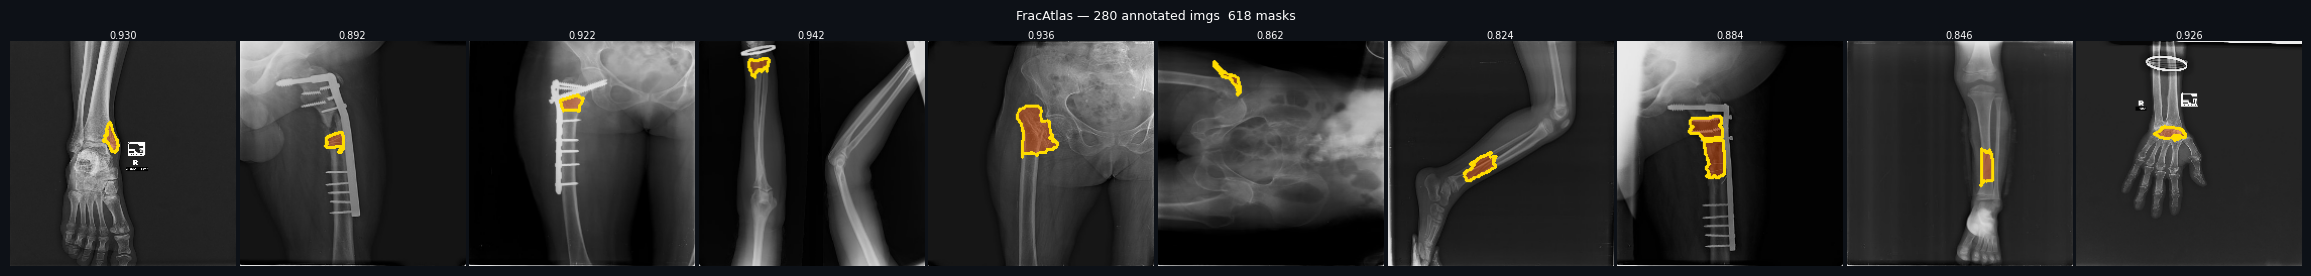

In [ ]:
# FracAtlas — 10 random masked images
show_masks(fa_imgs, fa_anns, 'FracAtlas')


In [ ]:
# Cell 8a — run_yolo функц
def run_yolo(root_path, src_name, id_start):
    root     = Path(root_path)
    img_dirs = [p for p in root.rglob('images') if p.is_dir()] or [root]
    imgs, anns = [], []
    iid=id_start; aid=1
    st={'ok':0,'neg':0,'metal':0,'filt':0}

    for img_dir in img_dirs:
        all_imgs = sorted([p for p in img_dir.rglob('*')
                           if p.suffix.lower() in {'.jpg','.jpeg','.png'}])
        for ip in tqdm(all_imgs, desc=src_name):
            lp = ip.with_suffix('.txt')
            if not lp.exists():
                lp = ip.parent.parent/'labels'/ip.with_suffix('.txt').name

            img_s,orig_s,oh,ow,sc = load_img(ip)
            if img_s is None: continue

            imgs.append({'id':iid,'file_name':ip.name,
                         'width':ow,'height':oh,'source':src_name})

            if not lp.exists() or lp.stat().st_size < 3:
                st['neg']+=1; iid+=1; continue
            lines=[l for l in lp.read_text().strip().split('\n') if l.strip()]
            if not lines: st['neg']+=1; iid+=1; continue

            if has_metal(orig_s): st['metal']+=1; iid+=1; continue

            predictor.set_image(img_s)
            for line in lines:
                pts=line.split()
                if len(pts)<5: continue
                try:
                    x1,y1,x2,y2=yolo_box(pts,oh,ow)
                    if (x2-x1)<5 or (y2-y1)<5: continue
                    box=np.array([x1*sc,y1*sc,x2*sc,y2*sc])
                    bm,pl,s=sam_predict(img_s,box,oh,ow)
                    if bm is None: st['filt']+=1; continue
                    anns.append({'id':aid,'image_id':iid,'category_id':1,
                                 'segmentation':pl,'bbox':[x1,y1,x2-x1,y2-y1],
                                 'area':int(bm.sum()),'iscrowd':0,
                                 'sam_score':round(s,4)})
                    aid+=1; st['ok']+=1
                except: st['filt']+=1
            iid+=1

    print(f'{src_name}: {st["ok"]} masks | neg {st["neg"]} | metal {st["metal"]} | filt {st["filt"]}')
    return imgs, anns


In [ ]:
# Cell 8b — YOLOBoneFracture
yb_imgs, yb_anns = run_yolo(
    '/content/datasets/YOLOBoneFracture/data/training',
    'YOLOBoneFracture', 10000)


YOLOBoneFracture: 100%|██████████| 3979/3979 [1:08:09<00:00,  1.03s/it]

YOLOBoneFracture: 1778 masks | neg 2002 | metal 37 | filt 468


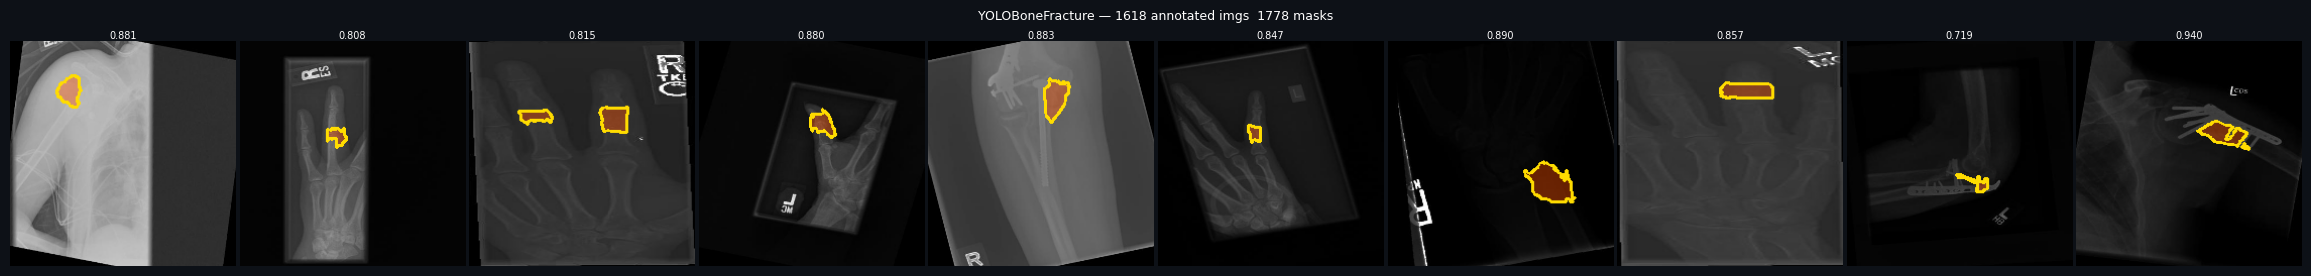

In [ ]:
# YOLOBoneFracture — 10 random masked images
show_masks(yb_imgs, yb_anns, 'YOLOBoneFracture')


In [ ]:
# Cell 8c — BoneFractureCVProject
cvp = Path('/content/datasets/BoneFractureCVProject')
cvd = next((p for p in cvp.rglob('images') if p.is_dir()), cvp)
cv_imgs, cv_anns = run_yolo(str(cvd), 'BoneFractureCVProject', 15000)


BoneFractureCVProject: 100%|██████████| 3631/3631 [1:02:21<00:00,  1.03s/it]

BoneFractureCVProject: 1629 masks | neg 1827 | metal 30 | filt 421


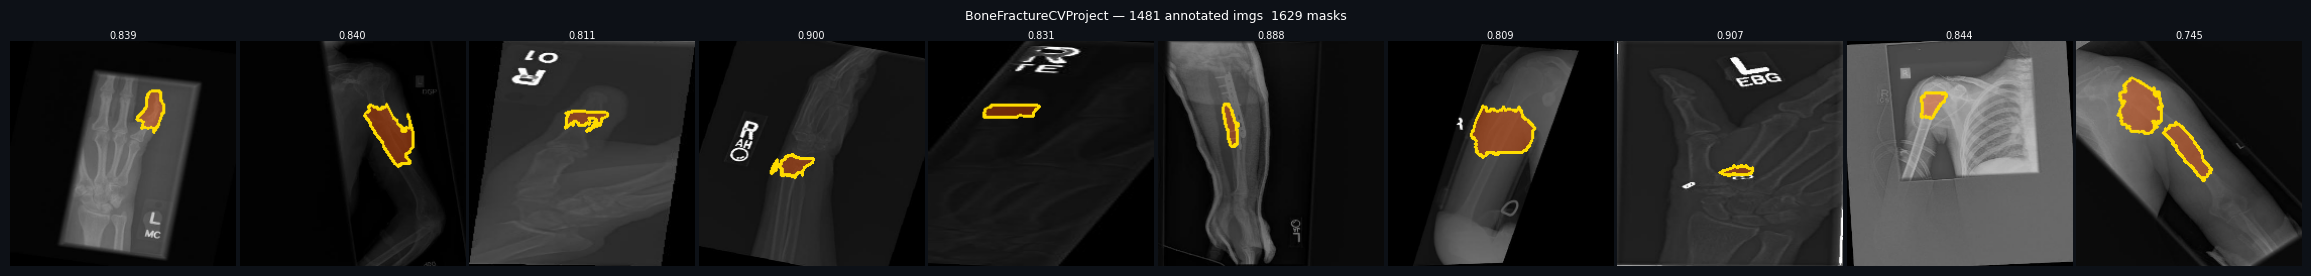

In [ ]:
# BoneFractureCVProject — 10 random masked images
show_masks(cv_imgs, cv_anns, 'BoneFractureCVProject')


In [ ]:
# Cell 8d — BoneFractureLiang
liang = Path('/content/datasets/BoneFracture4th')
if liang.exists() and any(liang.rglob('*.jpg')):
    ld = next((p for p in liang.rglob('images') if p.is_dir()), liang)
    lg_imgs, lg_anns = run_yolo(str(ld), 'BoneFracture4th', 20000)
else:
    print('BoneFracture4th: байхгүй, алгасна')
    lg_imgs, lg_anns = [], []


BoneFracture4th: байхгүй, алгасна


In [ ]:
# BoneFractureLiang — 10 random masked images
show_masks(lg_imgs, lg_anns, 'BoneFracture4th')


BoneFracture4th: харуулах маск байхгүй


In [ ]:
# Cell 9 — Нэгтгэх + статистик
import json, numpy as np
from collections import Counter

all_imgs = fa_imgs + yb_imgs + cv_imgs + lg_imgs
all_anns = []
ctr=1
for g in [fa_anns, yb_anns, cv_anns, lg_anns]:
    for a in g:
        x=dict(a); x['id']=ctr; all_anns.append(x); ctr+=1

id2src = {i['id']: i.get('source','?') for i in all_imgs}
cnt    = Counter(id2src.get(a['image_id'],'?') for a in all_anns)
scores = [a['sam_score'] for a in all_anns]

print('='*52)
print('SUMMARY')
print('='*52)
print(f'Total images     : {len(all_imgs):,}')
print(f'Annotated images : {len(set(a["image_id"] for a in all_anns)):,}')
print(f'Total masks      : {len(all_anns):,}')
print()
for src,n in cnt.most_common():
    print(f'  {src:30s}: {n:,}')
if scores:
    print(f'\nSAM score  mean:{np.mean(scores):.3f}  '
          f'min:{np.min(scores):.3f}  max:{np.max(scores):.3f}')

print(f'\n{"✓" if len(all_anns)>=3000 else "✗"} {len(all_anns):,} masks')

out = {
    'info': {
        'description': 'Fracture SAM Segmentation — clean pipeline',
        'preprocessing': 'CLAHE + metal filter',
        'quality_filter': f'score>={SCORE_THRESH}, area {MIN_AREA*100:.1f}-{MAX_AREA*100:.0f}%',
        'sources': list(cnt.keys()),
    },
    'categories': [{'id':1,'name':'fractured','supercategory':'bone'}],
    'images':      all_imgs,
    'annotations': all_anns,
}
with open('/content/fracture_sam_final.json','w') as f:
    json.dump(out, f, indent=2)
print('Saved → /content/fracture_sam_final.json')

SUMMARY
Total images     : 11,683
Annotated images : 3,379
Total masks      : 4,025

  YOLOBoneFracture              : 1,778
  BoneFractureCVProject         : 1,629
  FracAtlas                     : 618

SAM score  mean:0.837  min:0.700  max:0.988

✓ 4,025 masks
Saved → /content/fracture_sam_final.json


Маск бүхий зургийн тоо:
  FracAtlas: 280
  YOLOBoneFracture: 1618
  BoneFractureCVProject: 1481
  BoneFractureLiang: 0


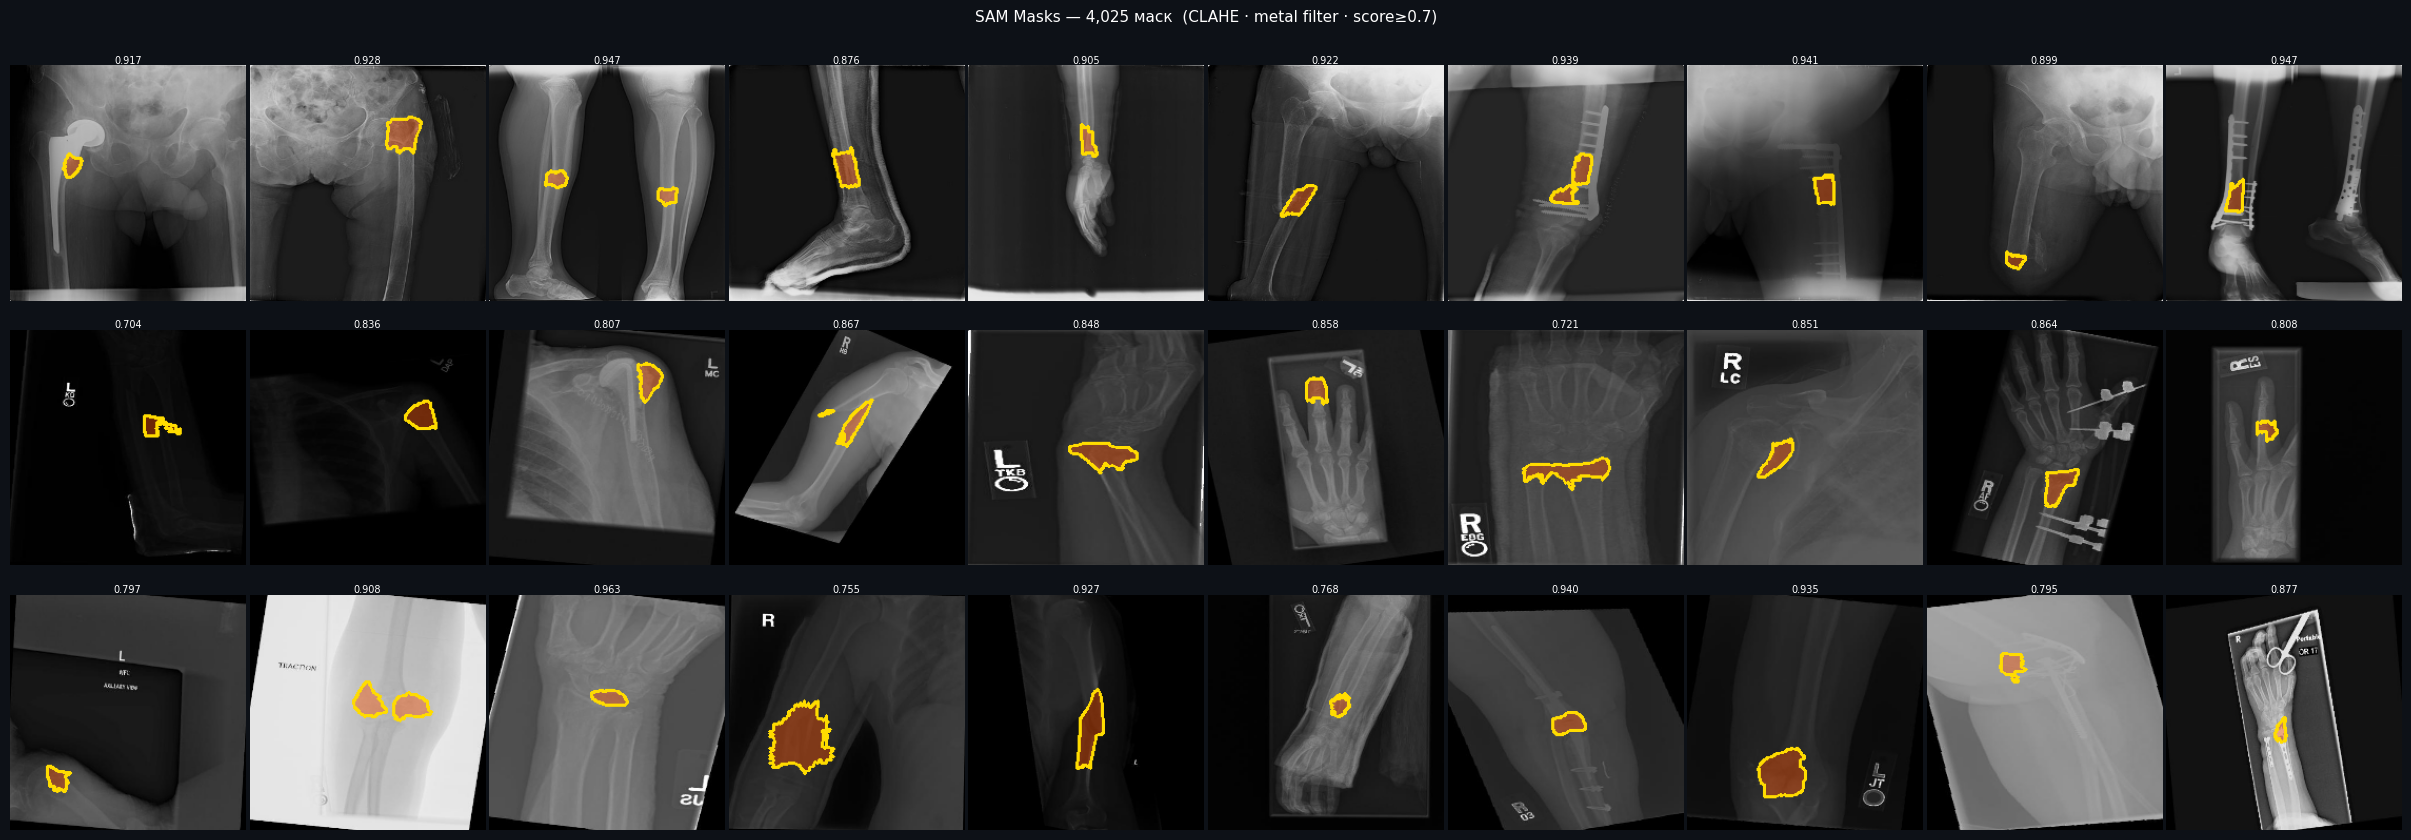

Saved → /content/fracture_sam_viz.png


In [ ]:
# Cell 10 — Visualization: dataset бүрээс 10 зураг
import random, cv2, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

DATA = Path('/content/datasets')
n2p  = {p.name:p for p in DATA.rglob('*')
        if p.is_file() and p.suffix.lower() in {'.jpg','.jpeg','.png'}}

i2info = {i['id']:i for i in all_imgs}
i2anns = {}
for a in all_anns: i2anns.setdefault(a['image_id'],[]).append(a)

SOURCES = ['FracAtlas','YOLOBoneFracture','BoneFractureCVProject','BoneFractureLiang']
COLORS  = {'FracAtlas':'#E74C3C','YOLOBoneFracture':'#2ECC71',
           'BoneFractureCVProject':'#F39C12','BoneFractureLiang':'#3498DB'}
N = 10

by_src = {s:[] for s in SOURCES}
for iid in i2anns:
    s = id2src.get(iid,'?')
    if s in by_src: by_src[s].append(iid)

print('Маск бүхий зургийн тоо:')
for s,ids in by_src.items():
    print(f'  {s}: {len(ids)}')

samples = {s: random.sample(ids,min(N,len(ids))) for s,ids in by_src.items()}

def draw(img_rgb, anns, sz=224):
    oh,ow = img_rgb.shape[:2]
    t  = cv2.resize(img_rgb,(sz,sz))
    sx,sy = sz/ow, sz/oh
    ov = t.copy().astype(np.float32)
    for a in anns:
        for poly in a['segmentation']:
            pts = np.array(poly).reshape(-1,2).copy()
            pts[:,0]*=sx; pts[:,1]*=sy
            cv2.fillPoly(ov,[pts.astype(np.int32)],[255,80,0])
    bl=(ov*.4+t.astype(np.float32)*.6).clip(0,255).astype(np.uint8)
    for a in anns:
        for poly in a['segmentation']:
            pts = np.array(poly).reshape(-1,2).copy()
            pts[:,0]*=sx; pts[:,1]*=sy
            cv2.polylines(bl,[pts.astype(np.int32)],True,(255,220,0),2)
    return bl

rows = [s for s in SOURCES if by_src.get(s)]
fig,axes = plt.subplots(len(rows),N,figsize=(N*2.4,len(rows)*2.8))
if len(rows)==1: axes=[axes]
fig.patch.set_facecolor('#0d1117')

for row,src in enumerate(rows):
    ids=samples.get(src,[])
    for col in range(N):
        ax=axes[row][col]
        ax.axis('off'); ax.set_facecolor('#0d1117')
        if col>=len(ids): continue
        info=i2info[ids[col]]
        anns=i2anns.get(ids[col],[])
        sp=n2p.get(info['file_name'])
        if sp is None: continue
        img=cv2.imread(str(sp))
        if img is None: continue
        vis=draw(cv2.cvtColor(img,cv2.COLOR_BGR2RGB),anns)
        ax.imshow(vis)
        sc=anns[0].get('sam_score',0) if anns else 0
        ax.set_title(f'{sc:.3f}',fontsize=7,color='white',pad=1)
        if col==0:
            ax.set_ylabel(src,fontsize=8,color=COLORS.get(src,'w'),
                          rotation=90,labelpad=4)

plt.suptitle(f'SAM Masks — {len(all_anns):,} маск  '
             f'(CLAHE · metal filter · score≥{SCORE_THRESH})',
             fontsize=11,color='white',y=1.01)
plt.tight_layout(pad=0.3)
plt.savefig('/content/fracture_sam_viz.png',dpi=130,
            bbox_inches='tight',facecolor='#0d1117')
plt.show()
print('Saved → /content/fracture_sam_viz.png')

In [ ]:
# Cell 11 — Google Drive-д хадгалах
import shutil, os, json
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive', force_remount=False)

OUT  = '/content/drive/MyDrive/fracture_dataset_ready'
os.makedirs(OUT, exist_ok=True)

# ── Зургийг source-аар дэд хавтсанд хадгална ─────────────────────────────
# file_name → source/filename болгоно (давхардал арилна)
with open('/content/fracture_sam_final.json') as f:
    coco = json.load(f)

# file_name-г source/original_name болгож шинэчлэх
for img in coco['images']:
    src = img.get('source', 'unknown')
    old = img['file_name']
    if not old.startswith(src + '/'):
        img['file_name'] = src + '/' + old

# шинэчлэгдсэн JSON хадгалах
out_json = f'{OUT}/fracture_sam_final.json'
with open(out_json, 'w') as f:
    json.dump(coco, f, indent=2)
print(f'JSON → {out_json}')

# sample_viz хуулах
try:
    shutil.copy('/content/fracture_sam_viz.png', f'{OUT}/sample_viz.png')
except: pass

# ── Зургуудыг source/ дэд хавтсанд хуулах ───────────────────────────────
DATA = Path('/content/datasets')
n2p  = {p.name: p for p in DATA.rglob('*')
        if p.is_file() and p.suffix.lower() in {'.jpg','.jpeg','.png'}}

ann_ids = set(a['image_id'] for a in coco['annotations'])
copied = missing = skipped = 0

for img in coco['images']:
    if img['id'] not in ann_ids:
        continue
    file_name = img['file_name']           # e.g. "YOLOBoneFracture/001.jpg"
    orig_name = Path(file_name).name       # "001.jpg"
    dst = Path(OUT) / 'images' / file_name
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists():
        skipped += 1; continue
    src = n2p.get(orig_name)
    if src is None:
        missing += 1; continue
    try:
        shutil.copy(src, dst)
        copied += 1
    except:
        missing += 1

print(f'Copied : {copied:,}')
print(f'Skipped: {skipped:,}')
print(f'Missing: {missing:,}')

total = copied + skipped
print(f'''
Drive:
  {OUT}/fracture_sam_final.json  ({len(coco["annotations"]):,} masks)
  {OUT}/images/  ({total:,} зураг)
    images/FracAtlas/
    images/YOLOBoneFracture/
    images/BoneFractureCVProject/''')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
JSON → /content/drive/MyDrive/fracture_dataset_ready/fracture_sam_final.json
Copied : 3,379
Skipped: 0
Missing: 0

Drive:
  /content/drive/MyDrive/fracture_dataset_ready/fracture_sam_final.json  (4,025 masks)
  /content/drive/MyDrive/fracture_dataset_ready/images/  (3,379 зураг)
    images/FracAtlas/
    images/YOLOBoneFracture/
    images/BoneFractureCVProject/
